### Data Visualization (Matplotlib)
### GOAL

👉 Learn:
- How to create graphs
- How to visualize data
- How to present insights (VERY IMPORTANT)

### STEP 1: Install Library

👉 Run once:

In [2]:
pip install matplotlib

### STEP 2: Import Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

### STEP 3: Load + Clean Data

In [4]:
from google.colab import files
uploaded = files.upload()

Saving sales.csv to sales.csv


In [7]:
df = pd.read_csv("sales.csv")

df["price"].fillna(df["price"].mean(), inplace=True)
df["quantity"].fillna(1, inplace=True)
df = df.drop_duplicates()
df = df.dropna(subset=["name"])

df["total"] = df["price"] * df["quantity"]

/tmp/ipykernel_6222/3535815963.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["price"].fillna(df["price"].mean(), inplace=True)
/tmp/ipykernel_6222/3535815963.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

### STEP 4: Bar Chart (Product Sales)

👉 Shows which product sells most

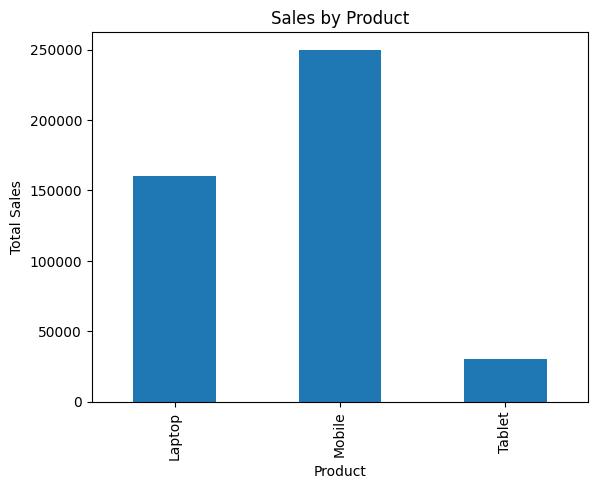

In [8]:
product_sales = df.groupby("product")["total"].sum()

product_sales.plot(kind="bar")

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.show()

### STEP 5: Line Chart (Trend)

👉 Shows pattern/trend

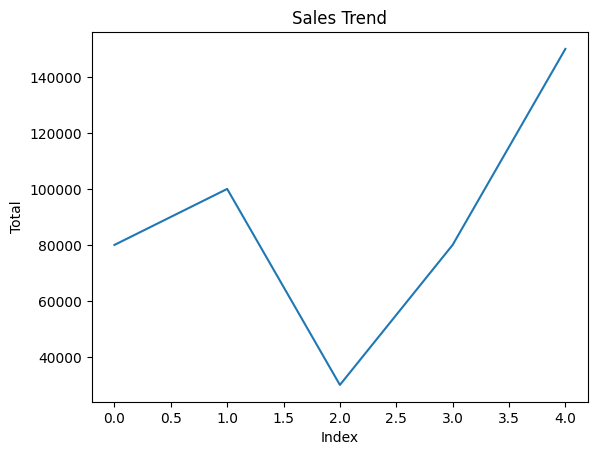

In [9]:
df["total"].plot(kind="line")

plt.title("Sales Trend")
plt.xlabel("Index")
plt.ylabel("Total")

plt.show()

### STEP 6: Pie Chart (City Contribution)

👉 Shows percentage share

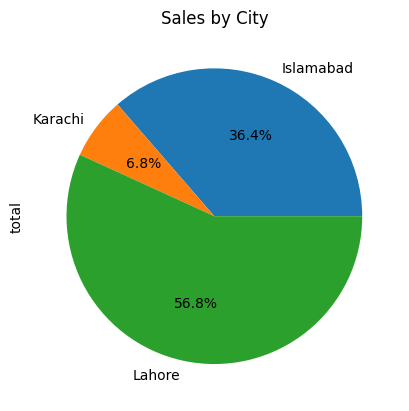

In [10]:
city_sales = df.groupby("city")["total"].sum()

city_sales.plot(kind="pie", autopct='%1.1f%%')

plt.title("Sales by City")

plt.show()

### STEP 7: Histogram (Distribution)

👉 Shows data distribution

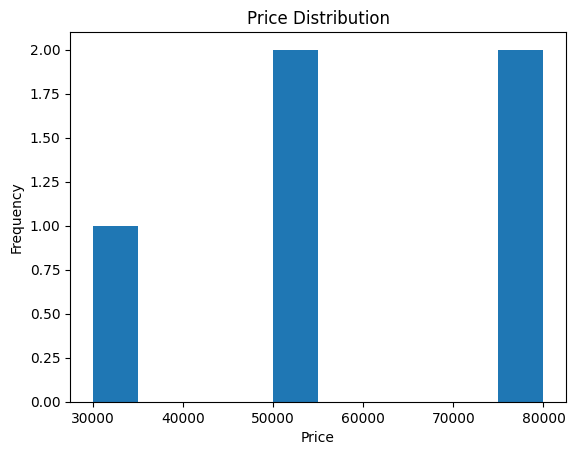

In [11]:
df["price"].plot(kind="hist")

plt.title("Price Distribution")
plt.xlabel("Price")

plt.show()

### Full Project
### STEP 1 — Upload CSV

In [16]:
from google.colab import files
uploaded = files.upload()
# Upload sales.csv

Saving sales.csv to sales (1).csv


### STEP 2 — Import libraries

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

### STEP 3 — Read the CSV file

In [18]:
df = pd.read_csv("sales.csv")

### STEP 4 — Check the data (VERY IMPORTANT DEBUG STEP)

In [19]:
print("First 5 rows:")
print(df.head())

print("\nColumns in dataset:")
print(df.columns)

print("\nData info:")
print(df.info())

First 5 rows:
     name product  price  quantity       city
0     Ali  Laptop  80000         1  Islamabad
1   Ahmed  Mobile  50000         2     Lahore
2    Sara  Tablet  30000         1    Karachi
3   Usman  Laptop  80000         1  Islamabad
4  Ayesha  Mobile  50000         3     Lahore

Columns in dataset:
Index(['name', 'product', 'price', 'quantity', 'city'], dtype='object')

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   name      5 non-null      object
 1   product   5 non-null      object
 2   price     5 non-null      int64 
 3   quantity  5 non-null      int64 
 4   city      5 non-null      object
dtypes: int64(2), object(3)
memory usage: 332.0+ bytes
None


 👉 If column names are wrong (like Product vs product), graphs will fail.
 ### MOST COMMON REAL PROBLEM
 dataset columns are usually like:
 ```
 Product, City, Price, Quantity
 ```
 But visualization expects:
 ```
 product, city, price, total
 ```
 So we must clean + prepare the data first.

 ### STEP 5 — Fix column names


In [20]:
# Convert column names to lowercase
df.columns = df.columns.str.lower()

print(df.columns)

Index(['name', 'product', 'price', 'quantity', 'city'], dtype='object')


### STEP 6 — Create TOTAL column (VERY IMPORTANT)
charts use total, but CSV usually doesn’t have it.

We must create it:

In [21]:
df["total"] = df["price"] * df["quantity"]

In [23]:
# Check again:
df.head()

,name,product,price,quantity,city,total
0,Ali,Laptop,80000,1,Islamabad,80000
1,Ahmed,Mobile,50000,2,Lahore,100000
2,Sara,Tablet,30000,1,Karachi,30000
3,Usman,Laptop,80000,1,Islamabad,80000
4,Ayesha,Mobile,50000,3,Lahore,150000


### STEP 7 — Visualization Function

In [24]:
def visualize_data(df):
    """
    Create graphs for sales analysis
    """

    # 1. Sales by Product (Bar Chart)
    plt.figure(figsize=(8,5))
    df.groupby("product")["total"].sum().plot(kind="bar")
    plt.title("Sales by Product")
    plt.xlabel("Product")
    plt.ylabel("Total Sales")
    plt.show()

    # 2. Sales by City (Pie Chart)
    plt.figure(figsize=(6,6))
    df.groupby("city")["total"].sum().plot(kind="pie", autopct='%1.1f%%')
    plt.title("Sales by City")
    plt.ylabel("")
    plt.show()

    # 3. Price Distribution (Histogram)
    plt.figure(figsize=(8,5))
    df["price"].plot(kind="hist", bins=10)
    plt.title("Price Distribution")
    plt.xlabel("Price")
    plt.show()

### STEP 8 — CALL THE FUNCTION (Final step)
Without this nothing shows.

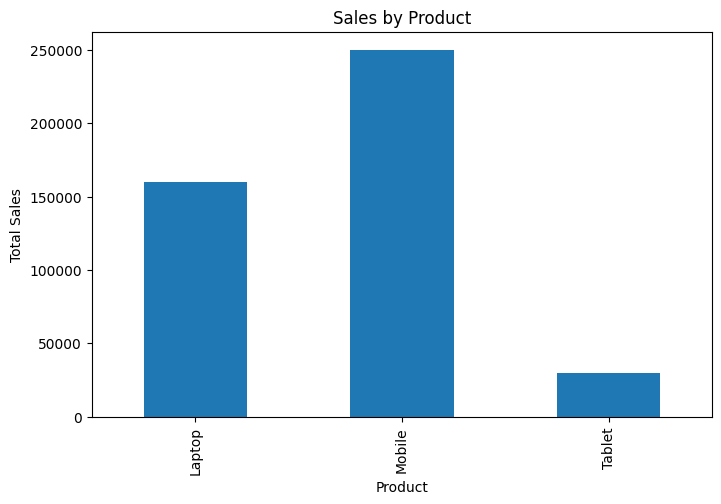

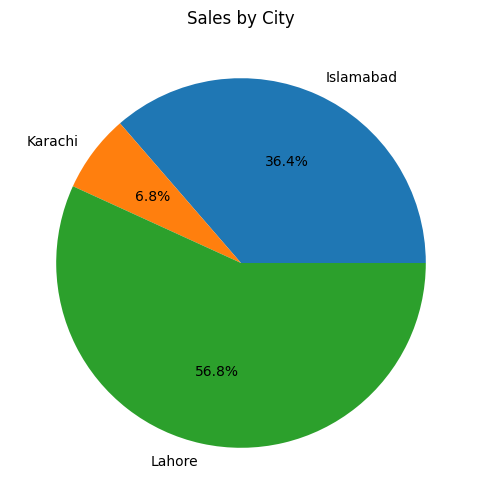

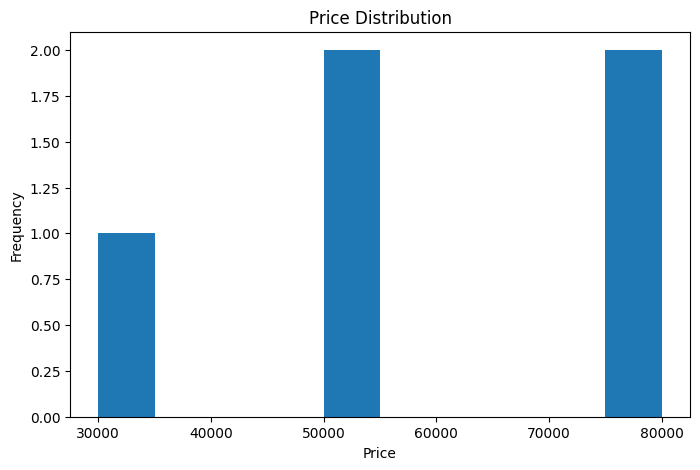

In [25]:
visualize_data(df)